In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import json
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
K_FRAME_PATH = Path("../data/k_frames/K1_recent.csv")
NORMALIZATION_PATH = Path("../data/processed/normalization_stats.json")

df = pd.read_csv(K_FRAME_PATH)

print(df.head())
print(df.groupby(["split", "class_name"]).size())

  split  site_id class_name  label  K strategy  selected_frame_count  \
0  test       26     looted      1  1   recent                     1   
1  test       27     looted      1  1   recent                     1   
2  test       29     looted      1  1   recent                     1   
3  test       30     looted      1  1   recent                     1   
4  test       31     looted      1  1   recent                     1   

   frame_1_index frame_1_name                                 frame_1_path  
0             95     mask.png  ..\data\processed_images\looted\26\mask.png  
1             94     mask.png  ..\data\processed_images\looted\27\mask.png  
2             95     mask.png  ..\data\processed_images\looted\29\mask.png  
3             94     mask.png  ..\data\processed_images\looted\30\mask.png  
4             94     mask.png  ..\data\processed_images\looted\31\mask.png  
split  class_name
test   looted         26
       preserved      35
train  looted         64
       prese

In [4]:
with open(NORMALIZATION_PATH, "r") as f:
    norm_stats = json.load(f)

mean = norm_stats["mean"]
std = norm_stats["std"]

print("Mean:", mean)
print("Std:", std)

Mean: [0.6641249441448802, 0.5746265725068144, 0.42835551291561075]
Std: [0.17935859533908458, 0.1680383227926673, 0.17305869328805765]


In [5]:
train = train
validation = val_1
test = test

NameError: name 'train' is not defined

In [6]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val_1"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print(train_df["label"].value_counts())
print(val_df["label"].value_counts())
print(test_df["label"].value_counts())

Train: 524
Val: 18
Test: 61
label
0    460
1     64
Name: count, dtype: int64
label
1    9
0    9
Name: count, dtype: int64
label
0    35
1    26
Name: count, dtype: int64


In [7]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [8]:
class SingleFrameDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["frame_1_path"]
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [9]:
BATCH_SIZE = 16

train_dataset = SingleFrameDataset(train_df, transform=train_transform)
val_dataset = SingleFrameDataset(val_df, transform=eval_transform)
test_dataset = SingleFrameDataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 33
Val batches: 2
Test batches: 4


In [10]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels)

torch.Size([16, 3, 224, 224])
torch.Size([16])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0])


In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 14 * 14, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
model = SimpleCNN(num_classes=2).to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=T

In [13]:
class_counts = train_df["label"].value_counts().sort_index()
print(class_counts)

num_preserved = class_counts[0]
num_looted = class_counts[1]

total = num_preserved + num_looted

weight_preserved = total / (2 * num_preserved)
weight_looted = total / (2 * num_looted)

class_weights = torch.tensor([weight_preserved, weight_looted], dtype=torch.float32).to(device)

print("Class weights:", class_weights)

label
0    460
1     64
Name: count, dtype: int64
Class weights: tensor([0.5696, 4.0938])


In [14]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [15]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [17]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = None

    cm = confusion_matrix(all_labels, all_preds)

    metrics = {
        "loss": epoch_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm
    }

    return metrics

In [18]:
EPOCHS = 10

best_val_f1 = 0.0
best_model_path = Path("../results/single_frame_cnn_best.pth")
best_model_path.parent.mkdir(parents=True, exist_ok=True)

history = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_metrics = evaluate(
        model, val_loader, criterion, device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']}"
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    })

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved ✅")


Epoch 1/10


100%|██████████| 2/2 [00:00<00:00,  4.35it/s]


Train Loss: 2.8775 | Train Acc: 0.6298
Val Loss: 1.5498 | Val Acc: 0.3889 | Val Precision: 0.4000 | Val Recall: 0.4444 | Val F1: 0.4211 | Val AUC: 0.39506172839506176
Best model saved ✅

Epoch 2/10


100%|██████████| 2/2 [00:00<00:00, 11.18it/s]


Train Loss: 0.8562 | Train Acc: 0.7424
Val Loss: 0.9024 | Val Acc: 0.3889 | Val Precision: 0.4167 | Val Recall: 0.5556 | Val F1: 0.4762 | Val AUC: 0.3580246913580247
Best model saved ✅

Epoch 3/10


...

Train Loss: 0.4435 | Train Acc: 0.7767
Val Loss: 0.9937 | Val Acc: 0.3889 | Val Precision: 0.4167 | Val Recall: 0.5556 | Val F1: 0.4762 | Val AUC: 0.3950617283950617

Epoch 9/10


100%|██████████| 2/2 [00:00<00:00, 11.29it/s]


Train Loss: 0.3923 | Train Acc: 0.8168
Val Loss: 1.5940 | Val Acc: 0.3889 | Val Precision: 0.4167 | Val Recall: 0.5556 | Val F1: 0.4762 | Val AUC: 0.3950617283950617

Epoch 10/10


100%|██████████| 2/2 [00:00<00:00,  9.94it/s]

Train Loss: 0.3969 | Train Acc: 0.8206
Val Loss: 0.8669 | Val Acc: 0.3889 | Val Precision: 0.4167 | Val Recall: 0.5556 | Val F1: 0.4762 | Val AUC: 0.3827160493827161


In [19]:
history_df = pd.DataFrame(history)
history_df.to_csv("../results/single_frame_cnn_history.csv", index=False)

history_df

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_auc
0,1,2.877459,0.629771,1.549826,0.388889,0.400000,0.444444,0.421053,0.395062
1,2,0.856197,0.742366,0.902382,0.388889,0.416667,0.555556,0.476190,0.358025
2,3,0.467385,0.822519,0.699338,0.444444,0.466667,0.777778,0.583333,0.370370
3,4,0.467932,0.795802,1.077208,0.388889,0.416667,0.555556,0.476190,0.382716
4,5,0.425152,0.809160,1.121267,0.333333,0.363636,0.444444,0.400000,0.382716
5,6,0.428296,0.803435,0.799554,0.500000,0.500000,0.777778,0.608696,0.382716
6,7,0.383796,0.832061,0.924394,0.388889,0.428571,0.666667,0.521739,0.395062
7,8,0.443469,0.776718,0.993718,0.388889,0.416667,0.555556,0.476190,0.395062
8,9,0.392276,0.816794,1.593981,0.388889,0.416667,0.555556,0.476190,0.395062
9,10,0.396888,0.820611,0.866915,0.388889,0.416667,0.555556,0.476190,0.382716


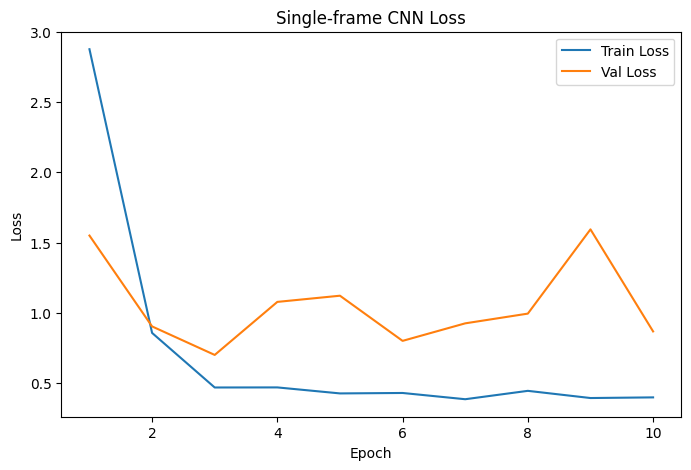

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Single-frame CNN Loss")
plt.legend()
plt.show()

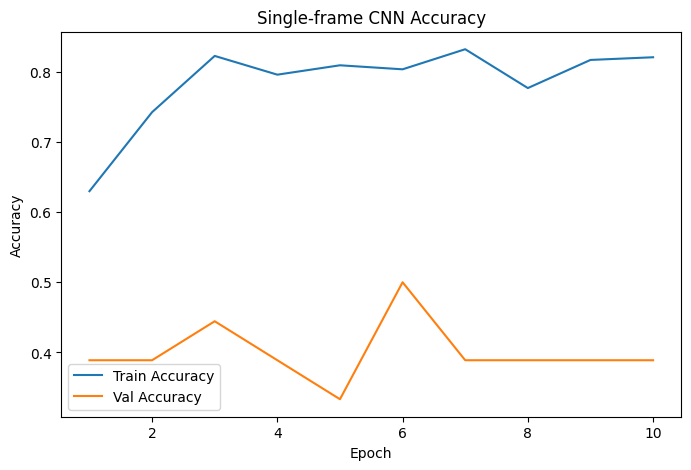

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Single-frame CNN Accuracy")
plt.legend()
plt.show()

In [22]:
best_model = SimpleCNN(num_classes=2).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_metrics = evaluate(best_model, test_loader, criterion, device)

print("Test Results:")
print("Accuracy:", test_metrics["accuracy"])
print("Precision:", test_metrics["precision"])
print("Recall:", test_metrics["recall"])
print("F1:", test_metrics["f1"])
print("AUC:", test_metrics["auc"])
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

100%|██████████| 4/4 [00:01<00:00,  3.64it/s]

Test Results:
Accuracy: 0.5409836065573771
Precision: 0.47619047619047616
Recall: 0.7692307692307693
F1: 0.5882352941176471
AUC: 0.6967032967032967
Confusion Matrix:
[[13 22]
 [ 6 20]]


In [23]:
test_result_df = pd.DataFrame([{
    "model": "single_frame_cnn",
    "K": 1,
    "strategy": "recent",
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"]
}])

test_result_df.to_csv("../results/single_frame_cnn_test_results.csv", index=False)

test_result_df

,model,K,strategy,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,single_frame_cnn,1,recent,0.540984,0.47619,0.769231,0.588235,0.696703


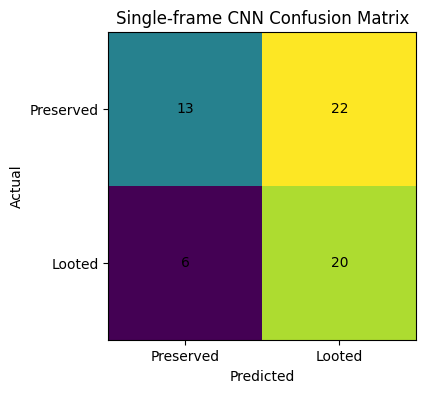

In [24]:
cm = test_metrics["confusion_matrix"]

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Single-frame CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Preserved", "Looted"])
plt.yticks([0, 1], ["Preserved", "Looted"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()